# 13. 건강 데이터 프로젝트 시작: 당뇨병 위험 예측 Baseline

이번 장에서는 건강 지표 데이터를 사용해 당뇨병 여부를 예측하는 baseline 모델을 만듭니다.

중요한 표현:

```text
이 모델은 의학적 진단 도구가 아닙니다.
딥러닝 학습을 위한 교육용 건강 위험 예측 예제입니다.
```

## 1. 라이브러리 불러오기

이번 장에서는 표 데이터를 다루므로 `pandas`, `scikit-learn`, `keras`를 함께 사용합니다.

In [1]:
# pathlib.Path는 파일 경로를 다루기 위한 도구입니다.
from pathlib import Path

# numpy는 숫자 배열을 다루는 라이브러리입니다.
import numpy as np

# pandas는 표 형태의 데이터를 읽고 다루는 라이브러리입니다.
import pandas as pd

# matplotlib.pyplot은 그래프를 그릴 때 사용합니다.
import matplotlib.pyplot as plt

# train_test_split은 데이터를 학습용과 검증용으로 나누는 함수입니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 숫자 특성을 평균 0, 표준편차 1 근처로 맞추는 도구입니다.
from sklearn.preprocessing import StandardScaler

# confusion_matrix는 정답과 예측이 어떻게 엇갈렸는지 표로 만들어 줍니다.
# classification_report는 precision, recall, f1-score를 계산해 줍니다.
from sklearn.metrics import confusion_matrix, classification_report

# Sequential은 Keras에서 층을 순서대로 쌓는 모델 방식입니다.
from keras.models import Sequential

# Input은 모델에 들어올 데이터 모양을 알려주는 층입니다.
# Dense는 완전연결층입니다.
# Dropout은 과적합을 줄이기 위해 학습 중 일부 출력을 임시로 끄는 층입니다.
from keras.layers import Input, Dense, Dropout

# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 읽기

사용할 파일은 BRFSS 기반 당뇨병 이진 분류 데이터입니다.

타깃 컬럼은 `Diabetes_binary`입니다.

In [2]:
# 데이터 파일 경로입니다.
DATA_PATH = Path(r"C:\work\dataset\diabetes_or_cardiovascular\diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

print("파일 존재 여부:", DATA_PATH.exists())

# read_csv()는 CSV 파일을 pandas DataFrame으로 읽어옵니다.
# DataFrame은 엑셀 표와 비슷한 형태라고 생각하면 됩니다.
df = pd.read_csv(DATA_PATH)

# shape는 행과 열의 개수를 보여줍니다.
print("데이터 shape:", df.shape)

# head()는 앞쪽 몇 행을 미리 보여줍니다.
df.head()

파일 존재 여부: True
데이터 shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## 3. 컬럼과 결측치 확인

모델을 만들기 전에 컬럼 이름과 비어 있는 값이 있는지 확인합니다.

결측치란 값이 비어 있는 칸을 뜻합니다.

In [3]:
# columns는 데이터프레임의 컬럼 이름 목록입니다.
print("컬럼 목록:")
print(list(df.columns))

# isna()는 값이 비어 있는지 True/False로 표시합니다.
# sum()을 붙이면 컬럼별 결측치 개수를 셉니다.
missing_counts = df.isna().sum()

print("\n결측치 개수:")
print(missing_counts)

컬럼 목록:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

결측치 개수:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


## 4. 타깃 분포 확인

타깃은 모델이 맞혀야 하는 정답입니다.

이번 데이터의 타깃은 다음 컬럼입니다.

```text
Diabetes_binary
```

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


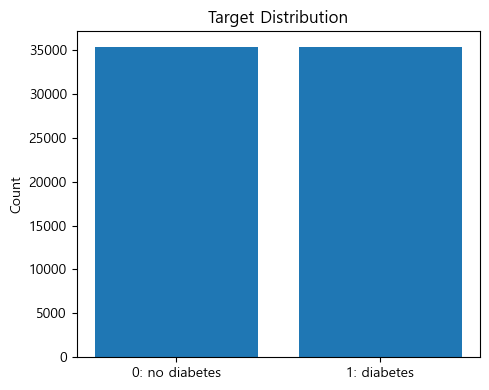

In [4]:
TARGET = "Diabetes_binary"

# value_counts()는 값별 개수를 세어 줍니다.
target_counts = df[TARGET].value_counts().sort_index()

print(target_counts)

plt.figure(figsize=(5, 4))
plt.bar(["0: no diabetes", "1: diabetes"], target_counts.values)
plt.title("Target Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 5. 입력 X와 정답 y 나누기

딥러닝 모델은 입력을 보고 정답을 맞히도록 학습합니다.

```text
X = 모델에게 보여줄 건강 지표들
y = 모델이 맞혀야 할 당뇨병 여부
```

In [5]:
# drop()은 특정 컬럼을 제거한 새 DataFrame을 만듭니다.
# axis=1은 행이 아니라 열을 제거한다는 뜻입니다.
X = df.drop(columns=[TARGET])

# y에는 정답 컬럼만 담습니다.
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70692, 21)
y shape: (70692,)


## 6. 학습 데이터와 검증 데이터 나누기

모델이 공부할 데이터와 시험 볼 데이터를 나눕니다.

검증 데이터를 따로 두는 이유는 모델이 처음 보는 데이터에서도 잘 맞히는지 확인하기 위해서입니다.

In [6]:
# train_test_split()은 데이터를 학습용과 검증용으로 나눕니다.
# test_size=0.2는 전체 중 20%를 검증용으로 쓰겠다는 뜻입니다.
# stratify=y는 y의 0/1 비율이 학습/검증 데이터에 비슷하게 유지되도록 합니다.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train 분포:")
print(y_train.value_counts(normalize=True).sort_index())
print("y_val 분포:")
print(y_val.value_counts(normalize=True).sort_index())

X_train shape: (56553, 21)
X_val shape: (14139, 21)
y_train 분포:
Diabetes_binary
0.0    0.499991
1.0    0.500009
Name: proportion, dtype: float64
y_val 분포:
Diabetes_binary
0.0    0.500035
1.0    0.499965
Name: proportion, dtype: float64


## 7. 스케일링

표 데이터에는 BMI처럼 숫자 범위가 큰 컬럼도 있고, 0/1로 된 컬럼도 있습니다.

신경망은 입력 숫자의 범위가 너무 제각각이면 학습이 불안정할 수 있습니다.

그래서 `StandardScaler`로 숫자 범위를 맞춥니다.

중요한 규칙:

```text
scaler.fit()은 학습 데이터에만 한다.
검증 데이터에는 transform()만 한다.
```

검증 데이터의 정보를 학습 단계에 몰래 쓰면 데이터 누출이 됩니다.

In [7]:
# StandardScaler 객체를 만듭니다.
scaler = StandardScaler()

# fit_transform()은 학습 데이터에서 평균/표준편차를 배우고, 그 기준으로 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# transform()은 이미 학습 데이터에서 배운 기준으로 검증 데이터를 변환합니다.
X_val_scaled = scaler.transform(X_val)

print("스케일링 전 X_train 예시:")
print(X_train.head(2))

print("\n스케일링 후 X_train_scaled 예시:")
print(X_train_scaled[:2])

스케일링 전 X_train 예시:
       HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
47977     1.0       0.0        1.0  29.0     1.0     0.0   
2676      0.0       1.0        1.0  24.0     1.0     0.0   

       HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  \
47977                   0.0           1.0     1.0      1.0  ...   
2676                    0.0           1.0     0.0      1.0  ...   

       AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  \
47977            1.0          0.0      2.0       0.0       0.0       0.0  1.0   
2676             1.0          0.0      3.0      15.0       6.0       0.0  0.0   

        Age  Education  Income  
47977  10.0        6.0     8.0  
2676    7.0        5.0     1.0  

[2 rows x 21 columns]

스케일링 후 X_train_scaled 예시:
[[ 0.88115891 -1.05242168  0.15838735 -0.11989653  1.05040873 -0.25610572
  -0.41567751  0.65052473  0.79586053  0.51829554 -0.20955681  0.21814714
  -0.32147161 -0.74954086 -0.4597314  -0.57563179 -0.5802

## 8. Baseline MLP 모델 만들기

이번 모델은 복잡하지 않게 시작합니다.

```text
입력 건강 지표
-> Dense
-> Dropout
-> Dense
-> sigmoid
```

출력값은 0과 1 사이의 숫자입니다.

In [8]:
# 입력 특성 개수입니다.
# X_train_scaled의 열 개수와 같습니다.
input_dim = X_train_scaled.shape[1]

model = Sequential([
    # 입력 데이터는 특성 input_dim개를 가진 1차원 벡터입니다.
    Input(shape=(input_dim,)),
    
    # 첫 번째 Dense 층입니다.
    # relu는 음수는 0으로, 양수는 그대로 통과시키는 활성화 함수입니다.
    Dense(32, activation="relu"),
    
    # 과적합을 줄이기 위해 일부 출력을 학습 중 임시로 끕니다.
    Dropout(0.2),
    
    # 두 번째 Dense 층입니다.
    Dense(16, activation="relu"),
    
    # 이진 분류 출력층입니다.
    # sigmoid는 출력값을 0~1 사이로 바꿉니다.
    Dense(1, activation="sigmoid")
])

# summary()는 모델 구조와 파라미터 수를 보여줍니다.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

## 9. 모델 컴파일

컴파일은 학습 규칙을 정하는 단계입니다.

이번 문제는 이진 분류이므로 `binary_crossentropy`를 사용합니다.

In [9]:
model.compile(
    # adam은 자주 쓰이는 최적화 방법입니다.
    optimizer="adam",
    
    # binary_crossentropy는 0/1 이진 분류에서 사용하는 손실 함수입니다.
    loss="binary_crossentropy",
    
    # accuracy는 전체 중 맞힌 비율입니다.
    metrics=["accuracy"]
)

## 10. 모델 학습

`fit()`은 모델을 학습시키는 메서드입니다.

처음 baseline에서는 epoch를 작게 시작합니다.

In [10]:
EPOCHS = 10

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=64,
    verbose=1
)

Epoch 1/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7297 - loss: 0.5384 - val_accuracy: 0.7434 - val_loss: 0.5110
Epoch 2/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7491 - loss: 0.5134 - val_accuracy: 0.7493 - val_loss: 0.5077
Epoch 3/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7504 - loss: 0.5107 - val_accuracy: 0.7491 - val_loss: 0.5064
Epoch 4/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7512 - loss: 0.5083 - val_accuracy: 0.7492 - val_loss: 0.5049
Epoch 5/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7512 - loss: 0.5070 - val_accuracy: 0.7496 - val_loss: 0.5042
Epoch 6/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7518 - loss: 0.5062 - val_accuracy: 0.7503 - val_loss: 0.5048
Epoch 7/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7527 - loss: 0.5050 - val_accuracy: 0.7515 - val_loss: 0.5033
Epoch 8/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7535 - loss: 0.5041 - val_accuracy: 0.

## 11. 학습 곡선 확인

학습 정확도와 검증 정확도를 함께 봅니다.

학습 정확도만 계속 올라가고 검증 정확도가 떨어지면 과적합을 의심할 수 있습니다.

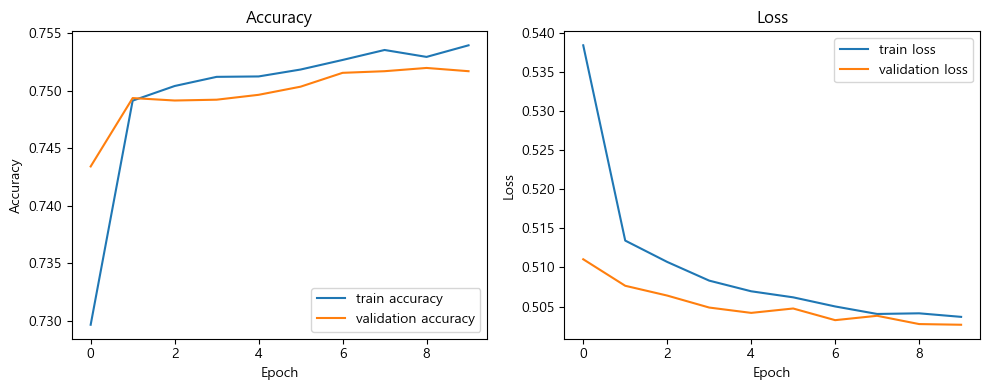

In [11]:
history_dict = history.history

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="train accuracy")
plt.plot(history_dict["val_accuracy"], label="validation accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="train loss")
plt.plot(history_dict["val_loss"], label="validation loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 12. 예측 확률과 0/1 예측 만들기

sigmoid 출력은 0과 1 사이의 확률 같은 값입니다.

보통 0.5 이상이면 1, 0.5 미만이면 0으로 바꿉니다.

이 0.5를 임계값(threshold)이라고 부릅니다.

In [12]:
# predict()는 모델의 예측 확률을 반환합니다.
y_val_prob = model.predict(X_val_scaled, verbose=0).ravel()

# 0.5 이상이면 1, 아니면 0으로 바꿉니다.
threshold = 0.5
y_val_pred = (y_val_prob >= threshold).astype(int)

print("예측 확률 앞 10개:")
print(y_val_prob[:10])

print("\n0/1 예측 앞 10개:")
print(y_val_pred[:10])

예측 확률 앞 10개:
[0.84280026 0.7849632  0.5011127  0.01898246 0.7550694  0.8256526
 0.439284   0.77025574 0.51270854 0.5989306 ]

0/1 예측 앞 10개:
[1 1 1 0 1 1 0 1 1 1]


## 13. Confusion Matrix와 Classification Report

모델 평가에서는 accuracy만 보지 않습니다.

특히 건강 위험 예측에서는 precision과 recall을 함께 봐야 합니다.

In [13]:
# confusion_matrix()는 정답과 예측이 어떻게 엇갈렸는지 보여줍니다.
cm = confusion_matrix(y_val, y_val_pred)

cm_df = pd.DataFrame(
    cm,
    index=["actual 0", "actual 1"],
    columns=["pred 0", "pred 1"]
)

cm_df

,pred 0,pred 1
actual 0,5013,2057
actual 1,1454,5615


In [14]:
# classification_report()는 precision, recall, f1-score를 한 번에 보여줍니다.
report = classification_report(
    y_val,
    y_val_pred,
    target_names=["no diabetes", "diabetes"],
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

 no diabetes       0.78      0.71      0.74      7070
    diabetes       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



## 14. 모델 저장

baseline 모델은 이후 개선 모델과 비교하기 위해 저장해 둡니다.

In [15]:
MODEL_DIR = Path(r"C:\work\deepLearning\model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "diabetes_baseline_mlp.keras"

# save()는 모델 구조와 학습된 가중치를 저장합니다.
model.save(model_path)

print("저장 완료:", model_path)

저장 완료: C:\work\deepLearning\model\diabetes_baseline_mlp.keras


## 15. 이번 장 정리

이번 장에서 배운 핵심은 다음과 같습니다.

```text
1. 건강 데이터 프로젝트는 문제 정의가 먼저다.
2. Diabetes_binary는 당뇨병 여부를 나타내는 타깃이다.
3. 모델은 진단 도구가 아니라 교육용 위험 예측 예제다.
4. train_test_split으로 학습/검증 데이터를 나눈다.
5. scaler는 학습 데이터에만 fit하고 검증 데이터에는 transform만 한다.
6. baseline 모델은 이후 개선의 기준점이다.
```

## 과제

1. 이 데이터에서 입력 X와 정답 y가 각각 무엇인지 설명해보세요.
2. `stratify=y`를 사용하는 이유를 적어보세요.
3. `scaler.fit_transform(X_train)`과 `scaler.transform(X_val)`의 차이를 설명해보세요.
4. 건강 위험 예측에서 accuracy만 보면 왜 부족할 수 있는지 적어보세요.